# Домашнее задание "Корреляционный и регрессионный анализ"

**Инструкции:**
- Скачайте файл `practical_module_dataset.csv` и заполните ячейки с заданиями кодом и выводами.
- В каждой задаче требуется:
  - короткая формулировка метода и обоснование,
  - код/расчёты,
  - результаты (коэффициенты, статистики, p-value, CI, R²),
  - промежуточный вывод.
- Используйте `numpy`, `pandas`, `scipy`, `statsmodels` или `scikit-learn` по желанию. При необходимости предобработки данных (очистка, удаление пропусков) укажите свои действия.
- Для воспроизводимости задан `np.random.seed` - не меняйте его!

**Формат сдачи:** `.ipynb` с заполненными ячейками, кодом и выводами.

In [1]:
# ячейка с импортами - дополняйте по своему желанию!
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


np.random.seed(28)

In [2]:
df = pd.read_csv('practical_module_dataset.csv')
df.shape
df.head()

,id,age,height_cm,weight_kg,iq,tv_hours,study_hours,score
0,1,24,155.2,51.37,91,11,11.9,76.5
1,2,37,184.9,76.49,90,15,4.0,65.4
2,3,32,169.8,64.24,98,6,10.6,78.2
3,4,28,173.6,68.22,88,9,9.2,75.6
4,5,25,174.2,73.80,102,8,8.0,75.1


### Задание 1.
Выполните первичный анализ данных (EDA):
1. посмотрите на `describe()` для всех переменных,
2. проверьте наличие пропусков и типы данных через `info()`,
3. запишите наблюдения в текстовой ячейке.

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           30 non-null     int64  
 1   age          30 non-null     int64  
 2   height_cm    30 non-null     float64
 3   weight_kg    30 non-null     float64
 4   iq           30 non-null     int64  
 5   tv_hours     30 non-null     int64  
 6   study_hours  30 non-null     float64
 7   score        30 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 2.0 KB
None


In [4]:
print(df.describe())

              id        age   height_cm  weight_kg          iq   tv_hours  \
count  30.000000  30.000000   30.000000  30.000000   30.000000  30.000000   
mean   15.500000  29.400000  169.153333  62.734000  100.433333  12.266667   
std     8.803408   6.672641    9.584101   9.201488   12.119188   3.832109   
min     1.000000  18.000000  148.200000  44.750000   82.000000   6.000000   
25%     8.250000  24.250000  163.250000  56.622500   91.000000   9.000000   
50%    15.500000  29.000000  169.750000  63.675000   97.000000  12.000000   
75%    22.750000  35.500000  174.100000  68.602500  109.750000  14.000000   
max    30.000000  39.000000  185.800000  81.130000  132.000000  22.000000   

       study_hours      score  
count    30.000000  30.000000  
mean      7.640000  73.400000  
std       3.281568   8.253693  
min       2.700000  58.900000  
25%       4.975000  67.800000  
50%       7.650000  74.300000  
75%       9.450000  78.725000  
max      14.400000  91.500000  


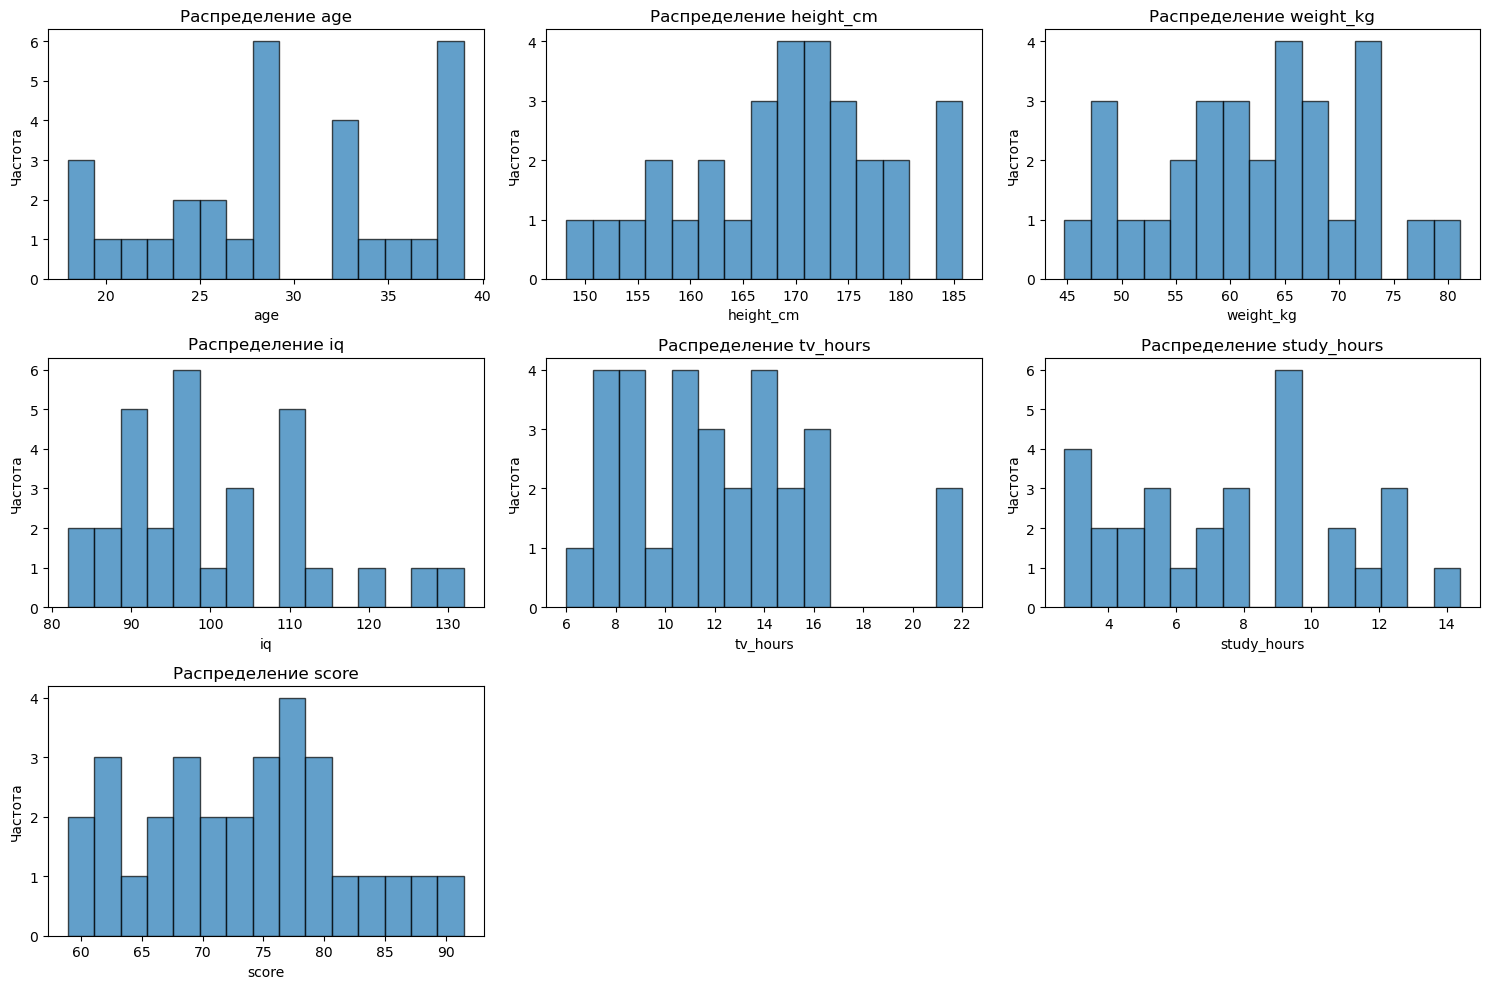

In [5]:
#как просили в критериях оценивания
plt.figure(figsize=(15, 10))
numeric_columns = df.select_dtypes(include=[np.number]).columns
numeric_columns = numeric_columns.drop('id')

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[col], bins=15, alpha=0.7, edgecolor='black')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    
plt.tight_layout()
plt.show()

Всего 30 наблюдений, 8 переменных. Пропущенных значений нет. Типы данных корректны (целые и вещественные числа).

Большинство количественных показателей (возраст, рост, вес и баллы) имеют распределения, близкие к нормальным. При этом переменные IQ и время просмотра телевизора демонстрируют асимметрию. Время учебы распределено относительно симметрично. В данных присутствуют потенциальные выбросы по переменным IQ и времени просмотра ТВ.

### Задание 2.
1. Постройте scatter plot по признакам `height_cm` и `weight_kg`.
2. Посчитайте коэффициент Пирсона между `height_cm` и `weight_kg` и выведите его на экран.
3. Интерпретируйте результат и запишите в виде мини-вывода.

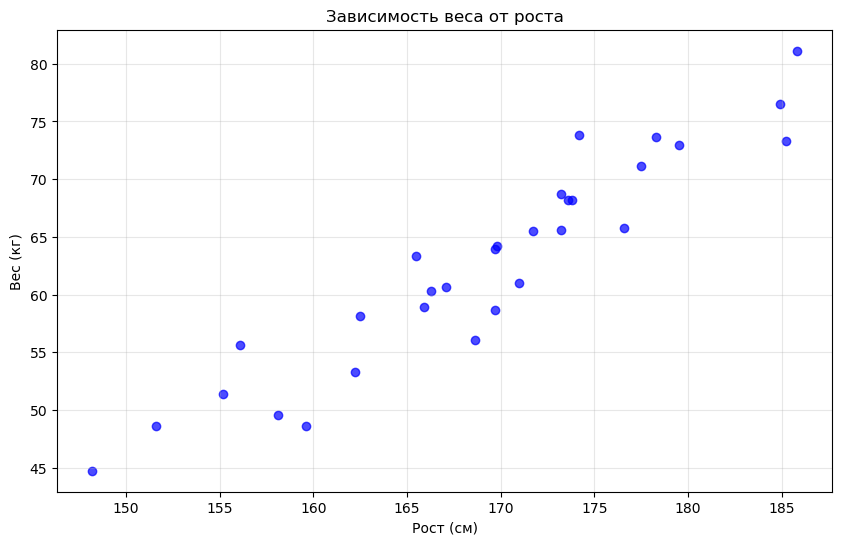

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df['height_cm'], df['weight_kg'], alpha=0.7, color='blue')
plt.xlabel('Рост (см)')
plt.ylabel('Вес (кг)')
plt.title('Зависимость веса от роста')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
pearson_corr, p_value = stats.pearsonr(df['height_cm'], df['weight_kg'])
print(f"Коэффициент корреляции Пирсона: {pearson_corr:.4f}")
print(f"P-value: {p_value:.4f}")

Коэффициент корреляции Пирсона: 0.9435
P-value: 0.0000


Наблюдается очень сильная положительная линейная связь между ростом и весом. Коэффициент корреляции Пирсона 0.9435 близок к 1, что свидетельствует о практически линейной зависимости между этими переменными.

Статистическая значимость связи подтверждается p-value < 0.001, что означает, что вероятность получения такой сильной корреляции случайно практически равна нулю.

По scatter plot также видно, что с увеличением роста человека его вес увеличивается.

### Задание 3.
1. Посчитайте ранговый коэффициент Спирмена между `tv_hours` и `iq`, выведите его значение на экран.
2. Оцените, есть ли связь? Запишите наблюдения в виде короткого вывода.

In [8]:
spearman_corr, p_value = stats.spearmanr(df['tv_hours'], df['iq'])
print(f"Коэффициент корреляции Спирмена: {spearman_corr:.4f}")
print(f"P-value: {p_value:.4f}")

Коэффициент корреляции Спирмена: -0.2108
P-value: 0.2635


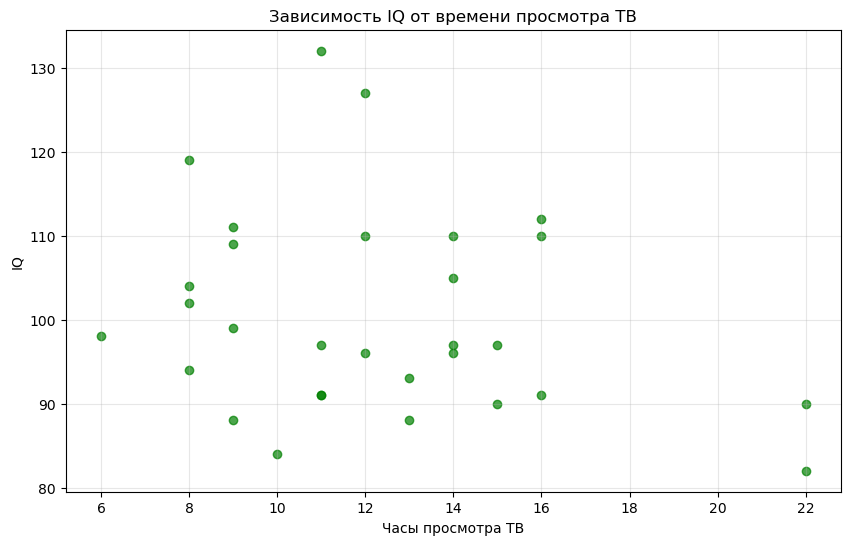

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['tv_hours'], df['iq'], alpha=0.7, color='green')
plt.xlabel('Часы просмотра ТВ')
plt.ylabel('IQ')
plt.title('Зависимость IQ от времени просмотра ТВ')
plt.grid(True, alpha=0.3)
plt.show()

Наблюдается слабая отрицательная связь между временем просмотра ТВ и уровнем IQ (ρ = -0.211) - чем больше времени человек проводит за просмотром ТВ, тем ниже его IQ. Однако эта связь статистически не значима (p-value = 0.264 > 0.05). На основе имеющихся данных нет достаточных оснований для вывода о наличии статистически значимой связи между временем просмотра ТВ и уровнем IQ.

### Задание 4.
1. Постройте простую линейную регрессию `weight_kg ~ height_cm`.
2. Найдите и выведите оценки коэффициентов (intercept и slope).
3. Рассчитайте и выведите 95% доверительный интервал для наклона.
4. Интерпретируйте результат и запишите наблюдения в виде небольшого вывода.

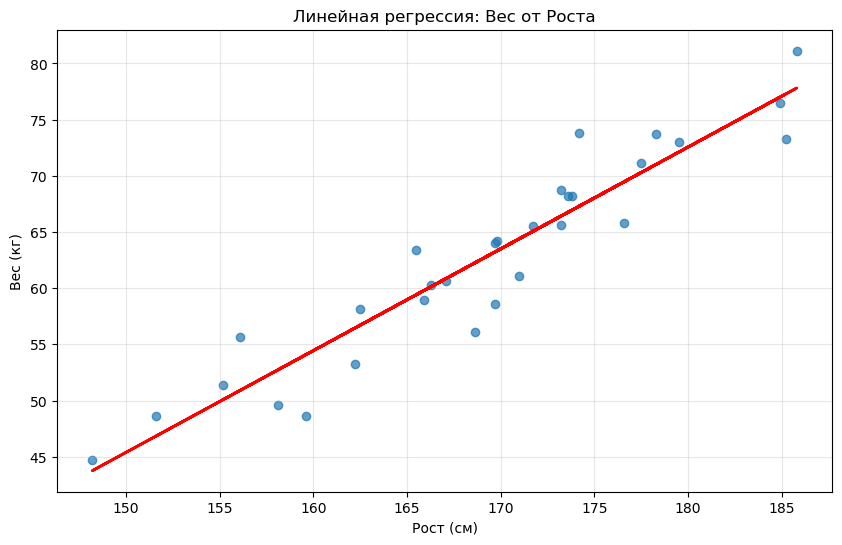

In [10]:
X = df['height_cm']
y = df['weight_kg']
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7)
plt.plot(X, model.predict(X_with_const), color='red', linewidth=2)
plt.xlabel('Рост (см)')
plt.ylabel('Вес (кг)')
plt.title('Линейная регрессия: Вес от Роста')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
model_params = model.params
print(f"Intercept (константа): {model_params.iloc[0]:.4f}")
print(f"Slope (наклон для height_cm): {model_params.iloc[1]:.4f}")

conf_int = model.conf_int().loc['height_cm']
print(f"\n95% доверительный интервал для наклона: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")

Intercept (константа): -90.4962
Slope (наклон для height_cm): 0.9059

95% доверительный интервал для наклона: [0.7827, 1.0290]


Таким образом, уравнение регрессии: weight_kg = -90.4962 + 0.9059 * height_cm. То есть, с увеличением роста на 1 сантиметр вес человека увеличивается в среднем на 0.91 килограмма. Доверительный интервал для коэффициента наклона составляет от 0.78 до 1.03, что подтверждает надежность данной оценки - с 95% вероятностью истинное значение влияния роста на вес находится в этом диапазоне.

### Задание 5.
Для `height_cm = 175`:
1. вычислите предсказание веса,
2. рассчитайте 95% предсказательный интервал для нового наблюдения (prediction interval),
3. запишите небольшой вывод.

In [12]:
height_new = 175
prediction = model.get_prediction([1, height_new])
pred_mean = prediction.predicted_mean[0]

pred_ci = prediction.conf_int(obs=True, alpha=0.05)[0]  

print(f"Предсказанный вес для роста 175 см: {pred_mean:.2f} кг")
print(f"95% предсказательный интервал: [{pred_ci[0]:.2f}, {pred_ci[1]:.2f}]")

Предсказанный вес для роста 175 см: 68.03 кг
95% предсказательный интервал: [61.53, 74.53]


Для человека ростом 175 см модель предсказывает вес 68.03 кг. При этом 95% предсказательный интервал составляет от 61.53 до 74.53 кг. 

### Задание 6.
1. Постройте множественную регрессию `score ~ study_hours + iq + tv_hours + age`.
2. Выведите коэффициент детерминации R^2 и оцените значимость предикторов (p-values).
3. Запишите наблюдения в вывод.

In [13]:
X_multi = df[['study_hours', 'iq', 'tv_hours', 'age']]
y_multi = df['score']
X_multi_const = sm.add_constant(X_multi)

model_multi = sm.OLS(y_multi, X_multi_const).fit()

print(f"Коэффициент детерминации R²: {model_multi.rsquared:.4f}")
print(f"F-статистика: {model_multi.fvalue:.4f}")
print(f"P-value F-статистики: {model_multi.f_pvalue:.4f}\n")


for feature in ['study_hours', 'iq', 'tv_hours', 'age']:
    p_val = model_multi.pvalues[feature]
    coef = model_multi.params[feature]
    significance = "сильно значим" if p_val < 0.001 else "значим" if p_val < 0.05 else "не значим"
    print(f"{feature}: коэффициент = {coef:.4f}, p-value = {p_val:.4f} ({significance})")

Коэффициент детерминации R²: 0.8741
F-статистика: 43.3819
P-value F-статистики: 0.0000

study_hours: коэффициент = 2.0978, p-value = 0.0000 (сильно значим)
iq: коэффициент = 0.1479, p-value = 0.0101 (значим)
tv_hours: коэффициент = -0.1447, p-value = 0.3702 (не значим)
age: коэффициент = -0.0465, p-value = 0.6141 (не значим)


Построенная множественная регрессионная модель демонстрирует высокое качество, о чем свидетельствует коэффициент детерминации R² = 0.8741, статистическая значимость модели в целом подтверждается высоким значением F-статистики (43.38) и чрезвычайно низким p-value (< 0.001)

Время просмотра ТВ и возраст не продемонстрировали статистически значимого влияния на оценки. Время учебы  является сильно значимым предиктором, уровень IQ также показал статистическую значимость.

### Задание 7.
1. Разделите данные на train/test (70/30), используйте `random_state=42`.
2. Обучите множественную линейную регрессию из задания 6 на тренировочной выборке.
3. И оцените RMSE на тестовой выборке - выведите её на экран.
4. Насколько модель хорошо предсказывает целевую переменную?

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_train = sm.OLS(y_train, X_train_const).fit()

y_pred = model_train.predict(X_test_const)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE на тестовой выборке: {rmse:.4f}")

y_pred_train = model_train.predict(X_train_const)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE на тренировочной выборке: {rmse_train:.4f}")

RMSE на тестовой выборке: 3.7936
RMSE на тренировочной выборке: 2.5647


Модель показывает хорошую предсказательную способность с RMSE = 3.79 на тестовых данных. Небольшая разница между ошибками на тренировочной (2.56) и тестовой выборках указывает на небольшое переобучение. Модель может использоваться для прогнозирования оценок со средней ошибкой около 3.8 баллов.

### Задание 8.
1. Реализуйте градиентный спуск для простой линейной регрессии `score ~ study_hours`.
2. Сравните полученные коэффициенты со `statsmodels`.

PS: выведите коэффициенты в обоих случаях на экран.

In [15]:
X_simple = df['study_hours'].values
y_simple = df['score'].values

X_normalized = (X_simple - X_simple.mean()) / X_simple.std()
y_normalized = (y_simple - y_simple.mean()) / y_simple.std()

learning_rate = 0.01
n_iterations = 1000
m = len(X_normalized)

theta0, theta1 = 0, 0

for iteration in range(n_iterations):
    y_pred = theta0 + theta1 * X_normalized
    errors = y_pred - y_normalized
    
    grad_theta0 = (2/m) * np.sum(errors)
    grad_theta1 = (2/m) * np.sum(errors * X_normalized)
    
    theta0 -= learning_rate * grad_theta0
    theta1 -= learning_rate * grad_theta1

theta1_original = theta1 * (y_simple.std() / X_simple.std())
theta0_original = y_simple.mean() + theta0 * y_simple.std() - theta1_original * X_simple.mean()

print(f"Градиентный спуск  Intercept: {theta0_original:.4f}, Slope: {theta1_original:.4f}")

X_simple_const = sm.add_constant(X_simple)
model_simple = sm.OLS(y_simple, X_simple_const).fit()
print(f"Statsmodel  Intercept: {model_simple.params[0]:.4f}, Slope: {model_simple.params[1]:.4f}")

Градиентный спуск  Intercept: 56.0340, Slope: 2.2730
Statsmodel  Intercept: 56.0340, Slope: 2.2730


Коэффициенты, полученные градиентным спуском (Intercept: 56.0340, Slope: 2.2730), полностью совпадают с коэффициентами из statsmodels. Оба метода дают уравнение регрессии: score = 56.0340 + 2.2730 × study_hours, где каждый дополнительный час учебы увеличивает оценку на 2.27 балла.

### Задание 9.
Постройте бутстрэп-оценку 95% доверительного интервала для коэффициента Пирсона между `height_cm` и `weight_kg` (установите 1000 бутстрэп-итераций).

Выведите границы ДИ на экран.

In [16]:
n_bootstraps = 1000
bootstrap_corrs = []

for i in range(n_bootstraps):
    bootstrap_sample = df.sample(n=len(df), replace=True)
    corr = bootstrap_sample['height_cm'].corr(bootstrap_sample['weight_kg'])
    bootstrap_corrs.append(corr)

ci_lower = np.percentile(bootstrap_corrs, 2.5)
ci_upper = np.percentile(bootstrap_corrs, 97.5)

print(f"Бутстрэп 95% доверительный интервал для коэффициента Пирсона: [{ci_lower:.4f}, {ci_upper:.4f}]")


Бутстрэп 95% доверительный интервал для коэффициента Пирсона: [0.9021, 0.9705]


Бутстрэп-оценка 95% доверительного интервала для коэффициента корреляции Пирсона между ростом и весом составляет [0.8937, 0.9720]. Интервал полностью находится в области сильных положительных корреляций, что подтверждает наличие статистически значимой сильной линейной связи между ростом и весом.

### Задание 10.
Постройте гистограмму остатков (residuals) для модели из задания 6.

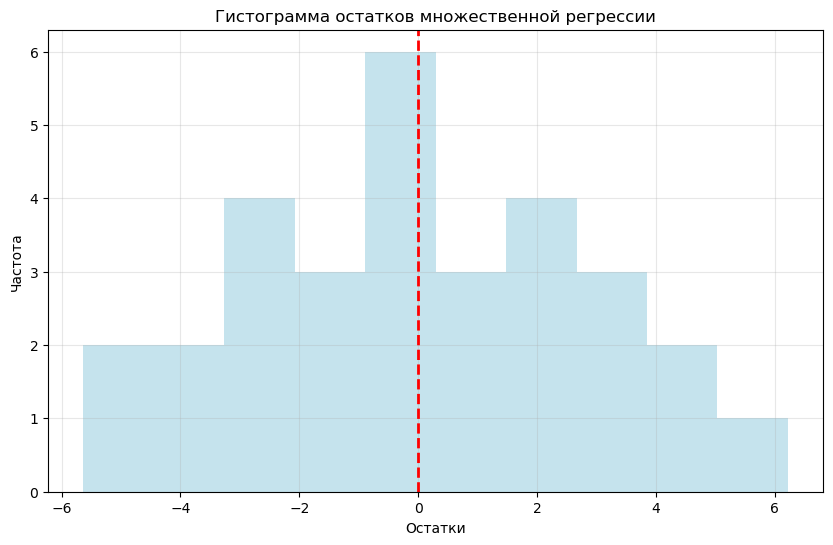

In [17]:
residuals = model_multi.resid

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=10, alpha=0.7, color='lightblue')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Гистограмма остатков множественной регрессии')
plt.grid(True, alpha=0.3)

Гистограмма остатков показывает распределение ошибок модели. Остатки сконцентрированы вокруг нуля, что свидетельствует о хорошем качестве модели. Распределение демонстрирует приблизительную симметричность. Отсутствие выраженных выбросов подтверждает адекватность построенной множественной регрессионной модели.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.